## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

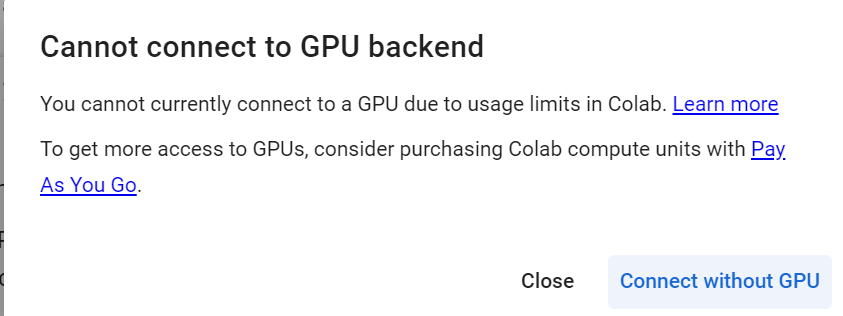

## Installing and Importing Necessary Libraries and Dependencies

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 66.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 280.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 225.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 275.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# For installing the libraries & downloading models from HF Hub
!pip install huggingface_hub==0.35.3 pandas==2.2.2 tiktoken==0.12.0 pymupdf==1.26.5 langchain==0.3.27 langchain-community==0.3.31 chromadb==1.1.1 sentence-transformers==5.1.1 numpy==2.3.3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.6/486.6 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458

In [ ]:
from IPython.display import Markdown

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
#Libraries for downloading and loading the llm
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

## Question Answering using LLM

### Downloading and Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [ ]:
model_path = hf_hub_download(
    repo_id= model_name_or_path, # the repo id
    filename= model_basename #the model name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path,
    n_ctx=2300,
    n_gpu_layers=38,
    n_batch=512
)

AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 1 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [ ]:
#uncomment the below snippet of code if the runtime is connected to CPU only.
#llm = Llama(
#    model_path=model_path,
#    n_ctx=1024,
#    n_cores=-2
#)

### Response

In [ ]:
def response(query,max_tokens=512,temperature=0,top_p=0.95,top_k=50):
    model_output = llm(
      prompt=query,
      max_tokens=max_tokens,
      temperature=temperature,
      top_p=top_p,
      top_k=top_k
    )

    return model_output['choices'][0]['text']

In [ ]:
response("What treatment options are available for managing hypertension?")

"\n\nHypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, and lean proteins; limiting sodium intake; getting regular physical activity; maintaining a healthy weight; and reducing stress through techniques such as meditation or deep breathing exercises.\n2. Medications: If lifestyle modifications alone are not enough to control hypertension, medications may be necessary. There are several classes of drugs used to treat hypertension, including diuretics, beta blockers, ACE inhibitors, calcium cha

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\n\nSepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:\n\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Sepsis can present with various clinical features, including fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.\n2. ABCs: Ensure airway patency, adequate breathing, and circulatory support. Provide high-flow oxygen via a non-rebreather mask or endotracheal tube if necessary. Initiate intravenous fluids to maintain adequate blood pressure and organ perfusion.\n3. Antibiotics: Administer broad-spectrum antibiotics as soon as possible based on the suspected source of infection and local microbiology data. Consider obtaining cultures before administering antibiotics if clin

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to define the query #2
response(user_input_2) # user input

Llama.generate: prefix-match hit


"\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small pouch-like structure that extends from the large intestine. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain is typically located in the lower right side of the abdomen and may be constant or come and go. It may start as a mild discomfort that worsens over time.\n2. Loss of appetite: People with appendicitis often lose their appetite due to abdominal pain and nausea.\n3. Nausea and vomiting: Vomiting is a common symptom of appendicitis, especially in the early stages.\n4. Fever: A fever may be present, particularly if the appendix has ruptured or perforated.\n5. Constipation or diarrhea: Some people with appendicitis experience constipation, while others have diarrhea.\n6. Abdominal swelling: The abdomen may become swollen and tender to the touch.\n7. Inability to pass gas: Passing gas can be difficult due to the press

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" # query #3
response(user_input_2) #user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, and eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications.\n\nThere are several treatments that have been shown to be effective in addressing sudden patchy hair loss:\n\n1. Corticosteroids: These are anti-inflammatory drugs that can help reduce inflammation and suppress the immune system's attack on the hair follicles. They can be applied topically or taken orally, depending on the severity of the condition.\n2. Minoxidil: This is a medication that has been shown to promote hair growth in some people with alopecia areata. It works by incre

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" # query #4
response(user_input_2) # user input

Llama.generate: prefix-match hit


"\n\nA person who has sustained a physical injury to the brain tissue may require various treatments depending on the severity and location of the injury. Here are some common treatments that may be recommended:\n\n1. Emergency care: In case of a traumatic brain injury (TBI), it is essential to seek emergency medical attention as soon as possible. The primary goal of emergency care is to prevent further damage to the brain, stabilize vital signs, and manage any life-threatening conditions.\n2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage various conditions associated with a brain injury, such as pain, swelling, seizures, or infections.\n3. Surgery: In some cases, surgery may be necessary to remove blood clots, repair skull fractures, or relieve pressure on the brain.\n4. Rehabilitation: Rehabilitation is an essential component of treatment for brain injuries. It may include physical therapy, occupational therapy, speech and langua

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" # query #5
response(user_input_2) # user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, if you suspect that someone has fractured their leg while hiking, it's essential to ensure their safety and prevent further injury. Here are some necessary precautions:\n\n1. Keep the person calm and still: Encourage them to remain as still as possible to minimize pain and prevent worsening the injury.\n2. Assess the situation: Check for any signs of shock, such as pale skin, rapid heartbeat, or shallow breathing. If you notice these symptoms, seek medical help immediately.\n3. Immobilize the leg: Use a splint, sling, or other available materials to immobilize the leg and prevent movement. Be sure not to apply too much pressure on the injury site.\n4. Provide pain relief: Offer over-the-counter pain medication, such as acetaminophen or ibuprofen, to help manage pain.\n5. Seek medical attention: If the fracture is severe or if you suspect that there may be other injuries, seek medical help as soon as possible.\n\nOnce you've ensured the person's safety and stabi

## Question Answering using LLM with Prompt Engineering

In [ ]:
#System prompt
system_prompt = """
[INST]<<SYS>>
You are a Clinical Assistant helping a doctor.
Your task is to give direct, professional answers,
to help doctors make quick and informed decisions in patient care.

Rules:
1. Do not give definitions or introductory "fluff" (e.g., "Hypertension is a common condition").
2. Get straight to the point so the answer doesn't get cut off.
3. Do not use polite conversational fillers like "I hope this helps."

Format:
- A 1-2 sentence direct summary of the answer.
- A bulleted list of specific treatment or management steps.
<<SYS>>[/INST]
"""

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = system_prompt+"\n"+ "What is the protocol for managing sepsis in a critical care unit?"
print(user_input)



[INST]<<SYS>>
You are a Clinical Assistant helping a doctor. 
Your task is to give direct, professional answers,
to help doctors make quick and informed decisions in patient care.

Rules:
1. Do not give definitions or introductory "fluff" (e.g., "Hypertension is a common condition").
2. Get straight to the point so the answer doesn't get cut off.
3. Do not use polite conversational fillers like "I hope this helps."

Format:
- A 1-2 sentence direct summary of the answer.
- A bulleted list of specific treatment or management steps.
<<SYS>>[/INST]

What is the protocol for managing sepsis in a critical care unit?


In [ ]:
Markdown(response(user_input))

Llama.generate: prefix-match hit




- Initiate broad-spectrum antibiotics as soon as possible.
- Administer fluid resuscitation to maintain adequate blood pressure and organ perfusion.
- Provide oxygen support via non-rebreather mask or mechanical ventilation if needed.
- Monitor and treat lactate levels, urine output, and electrolyte imbalances.
- Consider vasopressors for refractory hypotension.
- Implement source control measures for infection site (e.g., surgical intervention).
- Provide supportive care, including nutritional support and pain management.

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input = system_prompt+"\n"+ "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
Markdown(response(user_input)) # user input

Llama.generate: prefix-match hit




Symptoms: Abdominal pain (periumbilical or right lower quadrant), loss of appetite, nausea, vomiting, fever, and leukocytosis.

Treatment:
- Administer broad-spectrum antibiotics if diagnosis is uncertain but symptoms are worsening.
- Perform appendectomy as soon as possible if diagnosis is confirmed or symptoms become severe.
- Monitor for complications such as perforation, abscess formation, or sepsis during and after surgery.

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input = system_prompt + "\n" + "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
Markdown(response(user_input)) # user input

Llama.generate: prefix-match hit




1. Consider a diagnosis of alopecia areata, an autoimmune condition causing hair loss in patches.
2. Prescribe topical corticosteroids or intralesional triamcinolone for small areas to reduce inflammation and promote regrowth.
3. Explore other treatment options like minoxidil, anthralin, or immunotherapy if the condition persists or spreads.
4. Encourage stress management techniques, such as meditation, yoga, or counseling, as stress can worsen alopecia areata.
5. Advise against pulling or twisting hair and avoid tight hairstyles to prevent further damage.

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input = system_prompt + "\n" + "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
Markdown(response(user_input)) #user input

Llama.generate: prefix-match hit




- Consider rehabilitation therapy: occupational, speech, physical, and cognitive.
- Administer medications as needed: anti-inflammatory drugs, anticonvulsants, analgesics, and psychotropic agents.
- Monitor for complications: infections, hemorrhages, seizures, and edema.
- Provide supportive care: adequate nutrition, hydration, and rest.
- Consider surgical intervention if there is an intracranial hematoma or mass lesion.

In [ ]:
Markdown("""

A person who has sustained a physical injury to the brain tissue may require various treatments depending on the severity and location of the injury. Here are some common treatments that may be recommended:

1. Emergency care: In case of a traumatic brain injury (TBI), it is essential to seek emergency medical attention as soon as possible. The primary goal of emergency care is to prevent further damage to the brain, stabilize vital signs, and manage any life-threatening conditions.
2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage various conditions associated with a""")



A person who has sustained a physical injury to the brain tissue may require various treatments depending on the severity and location of the injury. Here are some common treatments that may be recommended:

1. Emergency care: In case of a traumatic brain injury (TBI), it is essential to seek emergency medical attention as soon as possible. The primary goal of emergency care is to prevent further damage to the brain, stabilize vital signs, and manage any life-threatening conditions.
2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage various conditions associated with a

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input = system_prompt + "\n" + "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
Markdown(response(user_input)) #user input

Llama.generate: prefix-match hit




1. Immobilize the affected leg using a splint or cast to prevent further damage and promote healing.
2. Administer pain medication as needed to manage discomfort.
3. Encourage elevation of the injured leg above heart level to reduce swelling and promote blood flow.
4. Provide crutches or other assistive devices for mobility.
5. Monitor for signs of infection, such as redness, warmth, or increased pain, and seek medical attention if present.
6. Encourage regular exercise and physical therapy to maintain muscle strength and flexibility during recovery.
7. Consider follow-up appointments with a healthcare professional to assess healing progress and adjust treatment plan as needed.

## Data Preparation for RAG

In [ ]:
#Libraries for processing dataframes,text
import json,os
import tiktoken
import pandas as pd

#Libraries for Loading Data, Chunking, Embedding, and Vector Databases
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

import warnings
warnings.filterwarnings("ignore")

### Loading the Data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
manual_pdf_path = "/content/drive/My Drive/PGP-AIML/M5 - NLP/Project/medical_diagnosis_manual.pdf"

In [ ]:
pdf_loader = PyMuPDFLoader(manual_pdf_path)

In [ ]:
manual = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [ ]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(manual[i].page_content,end="\n")

Page Number : 1
uday.kn01@gmail.com
YQKCVRO6I9
This file is meant for personal use by uday.kn01@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 2
uday.kn01@gmail.com
YQKCVRO6I9
This file is meant for personal use by uday.kn01@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    .......................................................................................................................................

#### Checking the number of pages

In [ ]:
len(manual)

4114

### Data Chunking

In [ ]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512, # chunk size
    chunk_overlap=20 # chunk overlap
)

In [ ]:
document_chunks = pdf_loader.load_and_split(text_splitter)

In [ ]:
len(document_chunks)

8477

In [ ]:
document_chunks[0].page_content

'uday.kn01@gmail.com\nYQKCVRO6I9\nThis file is meant for personal use by uday.kn01@gmail.com only.\nSharing or publishing the contents in part or full is liable for legal action.'

In [ ]:
document_chunks[2].page_content

'Table of Contents\n1\nFront    ................................................................................................................................................................................................................\n1\nCover    .......................................................................................................................................................................................................\n2\nFront Matter    ...........................................................................................................................................................................................\n53\n1 - Nutritional Disorders    ...............................................................................................................................................................\n53\nChapter 1. Nutrition: General Considerations    ...........................................................................................

In [ ]:
document_chunks[3].page_content

"Chapter 24. Testing for Hepatic & Biliary Disorders    ......................................................................................................\n305\nChapter 25. Drugs & the Liver    ................................................................................................................................................\n308\nChapter 26. Alcoholic Liver Disease    ....................................................................................................................................\n314\nChapter 27. Fibrosis & Cirrhosis    ............................................................................................................................................\n322\nChapter 28. Hepatitis    ..................................................................................................................................................................\n333\nChapter 29. Vascular Disorders of the Liver    .................................................

As expected, there are some overlaps

### Embedding

In [ ]:
embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large') # model name

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/670M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [ ]:
print("Dimension of the embedding vector ",len(embedding_1))
len(embedding_1)==len(embedding_2)

Dimension of the embedding vector  1024


True

In [ ]:
embedding_1,embedding_2

([-0.0017118649557232857,
  0.004401113837957382,
  -0.0015027393819764256,
  -0.01388875488191843,
  -0.024783363565802574,
  -0.04233887419104576,
  -0.012276685796678066,
  0.024918105453252792,
  0.008070811629295349,
  0.03228617087006569,
  0.020974021404981613,
  0.0045924438163638115,
  0.02380475215613842,
  -0.023345420137047768,
  -0.006709937006235123,
  0.003709144191816449,
  -0.01127349678426981,
  -0.03146812692284584,
  0.007693559397011995,
  0.01597386971116066,
  0.008956966921687126,
  0.015335703268647194,
  -0.06363563984632492,
  -0.03541744872927666,
  0.011427263729274273,
  0.03351932391524315,
  0.0037013620603829622,
  -0.02290167845785618,
  0.05218563228845596,
  0.03982893377542496,
  -0.012790154665708542,
  -0.002102225786074996,
  0.02614804357290268,
  -0.04382342845201492,
  -0.022314904257655144,
  -0.01631775125861168,
  0.05027861148118973,
  -0.02077484130859375,
  -0.033661287277936935,
  -0.046693649142980576,
  -0.0012924950569868088,
  -0.00

### Vector Database

In [ ]:
out_dir = 'medical_db'

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

In [ ]:
vectorstore = Chroma.from_documents(
    document_chunks, # document chunks
    embedding_model, # embedding model
    persist_directory=out_dir
)

In [ ]:
vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)

In [ ]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='thenlper/gte-large', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [ ]:
vectorstore.similarity_search("Black Hole",k=3) # query and an appropriate k value

[Document(metadata={'format': 'PDF 1.7', 'creationDate': 'D:20120615054440Z', 'subject': '', 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': '2012-06-15T05:44:40+00:00', 'keywords': '', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'moddate': '2026-03-04T02:00:03+00:00', 'author': '', 'file_path': '/content/drive/My Drive/PGP-AIML/M5 - NLP/Project/medical_diagnosis_manual.pdf', 'creator': 'Atop CHM to PDF Converter', 'page': 1830, 'modDate': 'D:20260304020003Z', 'trapped': '', 'total_pages': 4114, 'source': '/content/drive/My Drive/PGP-AIML/M5 - NLP/Project/medical_diagnosis_manual.pdf'}, page_content='radiosurgery, and endovascular surgery. AVMs that are deep or < 3 cm in diameter are treated with\nstereotactic radiosurgery, endovascular therapy (eg, preresection embolization or thrombosis via an intra-\narterial catheter), or coagulation with focused proton beams.\nAneurysms: Aneurysms are focal dilations in arteries. They occur in abou

### Retriever

In [ ]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 2} # k value
)

In [ ]:
user_query = "What are the common symptoms for appendicitis?" #Complete the code to define the query #2
rel_docs = retriever.get_relevant_documents(user_query) # query
rel_docs

[Document(metadata={'modDate': 'D:20260304020003Z', 'subject': '', 'author': '', 'total_pages': 4114, 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'creationDate': 'D:20120615054440Z', 'file_path': '/content/drive/My Drive/PGP-AIML/M5 - NLP/Project/medical_diagnosis_manual.pdf', 'page': 173, 'moddate': '2026-03-04T02:00:03+00:00', 'trapped': '', 'format': 'PDF 1.7', 'creator': 'Atop CHM to PDF Converter', 'creationdate': '2012-06-15T05:44:40+00:00', 'keywords': '', 'source': '/content/drive/My Drive/PGP-AIML/M5 - NLP/Project/medical_diagnosis_manual.pdf'}, page_content="Etiology\nAppendicitis is thought to result from obstruction of the appendiceal lumen, typically by lymphoid\nhyperplasia, but occasionally by a fecalith, foreign body, or even worms. The obstruction leads to\ndistention, bacterial overgrowth, ischemia, and inflammation. If untreated, necrosis, gangrene, and\nperforation occur. If the perfor

In [ ]:
model_output = llm(
      user_query, #the query
      max_tokens=512, # maximum number of tokens
      temperature=0, # temperature = randomness of the response.
    )

Llama.generate: prefix-match hit


In [ ]:
Markdown(model_output['choices'][0]['text'])



Appendicitis is a medical condition characterized by inflammation of the appendix, a small pouch located in the lower right side of the abdomen. The following are some common symptoms of appendicitis:

1. Abdominal pain: The most common symptom of appendicitis is a sharp pain that starts around the navel and then moves to the lower right side of the abdomen. The pain may be constant or come and go, and it may worsen with movement, coughing, or sneezing.
2. Loss of appetite: People with appendicitis often lose their appetite due to abdominal pain and discomfort.
3. Nausea and vomiting: Nausea and vomiting are common symptoms of appendicitis, especially in the early stages of the condition.
4. Fever: A fever of 100.4°F (38°C) or higher is a common symptom of appendicitis, particularly in more advanced cases.
5. Constipation or diarrhea: Appendicitis can cause constipation or diarrhea, depending on the location and severity of the inflammation.
6. Abdominal swelling: The abdomen may become swollen and tender to the touch in people with appendicitis.
7. Inability to pass gas: People with appendicitis may have difficulty passing gas due to inflammation and pressure on the intestines.
8. Pain upon movement or walking: Movement or walking can exacerbate the pain of appendicitis, making it difficult for people to move around comfortably.
9. Anxiety or restlessness: People with appendicitis may feel anxious or restless due to the discomfort and pain they are experiencing.
10. Urinary symptoms: In some cases, appendicitis can cause urinary symptoms such as a frequent urge to urinate, burning during urination, or difficulty passing urine.

It is important to note that these symptoms can also be caused by other conditions, so it is essential to consult a healthcare professional if you experience any of them. Appendicitis is a medical emergency that requires prompt treatment to prevent complications such as rupture of the appendix and peritonitis.

The above response is somewhat generic and is solely based on the data the model was trained on, rather than the medical manual.  

Let's now provide our own context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [ ]:
qna_system_message = """
You are an AI assistant whose work is to review the report and
provide relevant answers to the user question from the context.

User input will have the context required by you to answer user questions.
This context will begin with the token: ###Context.
The context contains references to specific portions
of a document relevant to the user query.

User questions will begin with the token: ###Question.

Please answer only using the context provided in the input.
Do not mention anything about the context in your final answer.

If the answer is not found in the context, respond "I don't know".

Format the output with a concise summary but don't include "summary" title,
followed by list of items as shown in the following example.
Do not include summary title.

"This is a sample summary for the user query"
1. List item 1
2. List item 2
...
...

"""

In [ ]:
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

### Response Function

In [ ]:
def generate_rag_response(user_input,k=3,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    prompt = qna_system_message + '\n' + user_message

    # Generate the response
    try:
        response = llm(
                  prompt=prompt,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        # Extract and print the model's response
        response = response['choices'][0]['text'].strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
output = generate_rag_response(user_input,top_k=20)
Markdown(output)

Llama.generate: prefix-match hit


"The protocol for managing sepsis in a critical care unit includes administering antibiotics as soon as possible, draining abscesses and excising necrotic tissues, normalizing blood glucose levels, and considering corticosteroid therapy. The specific antibiotic regimen depends on the suspected source and causative organisms. Gentamicin or tobramycin in combination with a 3rd-generation cephalosporin is one recommended option for septic shock of unknown cause. Vancomycin should be added if resistant staphylococci or

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
Markdown(generate_rag_response(user_input_2, top_k=20))

Llama.generate: prefix-match hit


This is a sample summary for the user query
1. Appendicitis is characterized by abdominal pain, anorexia, and abdominal tenderness.
2. Diagnosis of appendicitis is clinical but can be supplemented by CT or ultrasound.
3. Without surgery or antibiotics, mortality from appendicitis is over 50%.
4. Early surgical intervention (appendectomy) results in a low mortality rate and rapid recovery.
5. If the appendix ruptures or an abscess or peritonitis forms, the

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
Markdown(generate_rag_response(user_input_2, top_k=20) )

Llama.generate: prefix-match hit


1. Alopecia areata: This is a common autoimmune disorder that affects genetically susceptible individuals exposed to unclear environmental triggers. The most frequent treatments for alopecia areata include topical, intralesional, or systemic corticosteroids, topical minoxidil, topical anthralin, topical immunotherapy (diphencyprone or squaric acid dibutylester), or psoralen plus ultraviolet A (PUVA). The efficacy of these treatments varies and may take several months to show results.

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
Markdown(generate_rag_response(user_input_2, top_k=20) )

Llama.generate: prefix-match hit


1. Supportive care: Preventing systemic complications due to immobilization, providing good nutrition, and preventing pressure ulcers.
2. Treatment for seizures: If the person has significant structural injury (large contusions or hematomas, brain laceration, depressed skull fracture) or a Glasgow Coma Scale score of < 10, drugs are given to prevent seizures during the first week after injury. These drugs reduce the risk of seizures but do not prevent permanent posttraumatic epilepsy months or years later. They should be stopped after one week unless seizures

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
Markdown(generate_rag_response(user_input_2, top_k=20))

Llama.generate: prefix-match hit


1. The injured limb should be elevated above heart level for first 2 days to minimize swelling and allow gravity to help drain edema fluid.
2. After 48 hours, periodic application of warmth (heating pad) for 15 to 20 minutes may relieve pain and speed healing.
3. Immobilization is necessary to prevent further injury and facilitate healing. Joints proximal and distal to the injury should be immobilized.
4. A cast or splint can be used for immobilization, depending on the severity of the injury and the

### Fine-tuning

#### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
Markdown(generate_rag_response(user_input,temperature=0.5))

Llama.generate: prefix-match hit


1. Start empiric antibiotic therapy immediately after suspecting sepsis.
2. Administer gentamicin or tobramycin 5.1 mg/kg IV once/day plus a 3rd-generation cephalosporin (cefotaxime 2 g q 6 to 8 h or ceftriaxone 2 g once/day) for septic shock of unknown cause.
3. Consider adding vancomycin if resistant staphylococci or enterococci are suspected.
4. Drain abscess

#### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
Markdown(generate_rag_response(user_input_2, temperature=0.5))

Llama.generate: prefix-match hit


1. Appendicitis is a condition characterized by inflammation of the vermiform appendix. Common symptoms include abdominal pain, anorexia (loss of appetite), and abdominal tenderness.
2. No, appendicitis cannot be cured via medicine alone as it requires surgical removal to prevent complications such as perforation or rupture. The common surgical procedure for treating appendicitis is an open or laparoscopic appendectomy. This involves removing the appendix to prevent further spread of infection and promote healing. In some cases, IV fluids and

#### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
Markdown(generate_rag_response(user_input_2, temperature=0.5))

Llama.generate: prefix-match hit


1. For sudden patchy hair loss, also known as alopecia areata, there are multiple treatment options available. These include topical corticosteroids, intralesional corticosteroids, systemic corticosteroids, topical minoxidil, topical anthralin, topical immunotherapy (diphencyprone or squaric acid dibutylester), or psoralen plus ultraviolet A (PUVA).
2. The possible causes of sudden patchy hair loss could be an autoimmune disorder affecting genetically susceptible people exposed

#### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
Markdown(generate_rag_response(user_input_2, temperature=0.5))

Llama.generate: prefix-match hit


1. Supportive care: Preventing systemic complications due to immobilization, providing good nutrition, and preventing pressure ulcers are essential components of the treatment plan for a person with traumatic brain injury (TBI). There is no specific treatment for TBI, but supportive care should be provided to maintain adequate brain perfusion and oxygenation, prevent complications, and ensure rehabilitation if needed.
2. Initial treatment: In the first few days after the injury, maintaining adequate brain perfusion and oxygenation and preventing complications are crucial. Depending on the severity of the injury, surgery may

#### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
Markdown(generate_rag_response(user_input_2, temperature=0.5))

Llama.generate: prefix-match hit


1. Apply ice to the injured area for 15 to 20 minutes every day after the first 48 hours to relieve pain and speed healing.
2. Immobilize the limb using either a cast or a splint, depending on the severity of the injury and the length of immobilization required. Ensure that patients with casts keep them dry and inspect the edges and skin around the cast daily for any redness or soreness.
3. Elevate the injured limb above the heart for the first 2 days to help drain edema fluid and minimize swelling.

## Output Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation.

- We are using the same Mistral model for evaluation, so basically here the llm is rating itself on how well he has performed in the task.

In [ ]:
groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluaton criteria and assign a score.
"""

In [ ]:
relevance_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance measures how well the answer addresses the main aspects of the question, based on the context.
Consider whether all and only the important aspects are contained in the answer when evaluating relevance.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.
"""

In [ ]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [ ]:
def generate_ground_relevance_response(user_input,k=3,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=3)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)

    # Combine user_prompt and system_message to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query
                                                            , question=user_input)}
                [/INST]"""

    response = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    answer =  response["choices"][0]["text"]

    # Combine user_prompt and system_message to create the prompt
    groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    # Combine user_prompt and system_message to create the prompt
    relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    response_1 = llm(
            prompt=groundedness_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    response_2 = llm(
            prompt=relevance_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    return response_1['choices'][0]['text'],response_2['choices'][0]['text']

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
ground,rel = generate_ground_relevance_response(
    user_input="What is the protocol for managing sepsis in a critical care unit?",
    max_tokens=370)

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Steps to evaluate the answer:
1. Identify the key information in the context related to managing sepsis in a critical care unit.
2. Determine if the AI generated answer is derived only from the information presented in the context.
3. Evaluate the extent to which the metric is followed.

Explanation:
The context provides detailed information about the management of critically ill patients, including the importance of preventing infection and the protocols for investigating alarms.

 Steps to evaluate the context as per the relevance metric:
1. Identify the main aspects of the question, which are managing sepsis in a critical care unit and the protocols involved.
2. Search for information related to sepsis management in the context.
3. Determine if all important aspects of sepsis management are present in


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
ground,rel = generate_ground_relevance_response(
    user_input="What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?",
    max_tokens=370)
print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Steps to evaluate the answer:
1. Identify the key information in the context related to appendicitis and its treatment.
2. Determine if the AI generated answer includes only the information derived from the context.
3. Check if the answer mentions the symptoms of appendicitis correctly and if it states that surgery is required for treatment.
4. Ensure that the answer does not include any additional or incorrect information.

Explanation:
The AI generated answer adheres to the metric as it only includes the information derived from the context. The answer mentions the symptoms of appendicitis (abdominal pain, anorexia, and abdominal tenderness) correctly and states that surgery is required for treatment. There is no additional or incorrect information in the answer.

Evaluation:
The metric is followed completely.

Rating:
Based on the evaluation criteria, I would rate the answer as a 5 (The metric is followed completely).

 Steps to evaluate the context as per the relevance metric:
1. 

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
ground,rel = generate_ground_relevance_response(
    user_input="What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?",
    max_tokens=370)
print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Steps to evaluate the answer:
1. Identify the information related to treatments or solutions for sudden patchy hair loss from the context.
2. Compare the AI generated answer with the identified information to check if the answer is derived only from the context.
3. Evaluate the extent to which the metric is followed.

Explanation:
The AI generated answer mentions topical corticosteroids, immunotherapy, minoxidil, oral corticosteroids, and surgical options as effective treatments for sudden patchy hair loss

 Steps to evaluate the context as per the relevance metric:
1. Identify the main aspects of the question: Effective treatments or solutions for addressing sudden patchy hair loss and possible causes behind it.
2. Determine if all important aspects are covered in the context: The context mentions various treatments for alopecia areata, which is a type of sudden patchy hair loss. It also discusses possible causes


### Query 4: What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
ground,rel = generate_ground_relevance_response(
    user_input="What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?",
    max_tokens=370)
print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Steps to evaluate the answer:
1. Identify the information in the context related to treatments for traumatic brain injury (TBI).
2. Determine if the AI generated answer includes only the treatments mentioned in the context.
3. Evaluate the extent to which the answer adheres to the metric of being derived solely from the context.

Explanation:
The AI generated answer includes several treatments for TBI, such as supportive care, initial treatment, and medications for seizure prevention and long-term treatment. These treatments are all mentioned in the context provided. Therefore, the answer is derived entirely from the information presented in the context.

Rating:
Based on the evaluation criteria, I would rate this answer as a 5 because it follows the metric completely by deriving all of its information solely from the context.

 Steps to evaluate context as per relevance metric:
1. Identify the main aspects of the question: treatments for a person with brain injury.
2. Determine if th

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
ground,rel = generate_ground_relevance_response(
    user_input="What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?",
    max_tokens=370)
print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Steps to evaluate the answer:
1. Identify the information in the context related to precautions and treatment steps for a person who has fractured their leg during a hiking trip.
2. Check if each point in the AI generated answer is derived directly from the information presented in the context.

Explanation:
The AI generated answer adheres to the metric as it provides steps that are directly derived from the context. The context discusses various precautions and treatment steps for a person with a fractured leg, such as applying ice after 48 hours, immobilizing the limb using a cast or splint, keeping the cast dry, inspecting the edges and skin around the cast daily, seeking medical care if an odor emanates from within the cast or a fever develops, maintaining good hygiene, and considering early mobilization for fractures that require prolonged immobilization. The AI generated answer includes each of these steps, ensuring that the information is derived solely from the context.

Ratin

## Actionable Insights and Business Recommendations


*   
*  
*



<font size=6 color='blue'>Power Ahead</font>
___